# Transfer Learning with **MobileNet** & **Faster R-CNN** (PyTorch)

This notebook walks through **transfer learning** for two computer-vision tasks:

| Part | Model | Task | Dataset |
|------|-------|------|---------|
| **A** | MobileNet V2 | Image **classification** | Hymenoptera (ants vs bees) |
| **B** | Faster R-CNN (ResNet-50 FPN) | Object **detection** | Penn-Fudan Pedestrian |
| **C** | Faster R-CNN with a **MobileNet backbone** | Object **detection** | Penn-Fudan Pedestrian |

- **Hymenoptera** (~250 images, 2 classes): `https://download.pytorch.org/tutorial/hymenoptera_data.zip`
- **Penn-Fudan Pedestrian** (170 images, 345 pedestrians): `https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip`

## 0. What is Transfer Learning?

Instead of training a network from scratch, we take a model **pretrained on a huge dataset** (ImageNet, COCO) and adapt it to our smaller problem. Two common strategies:

1. **Feature extraction** — freeze the pretrained convolutional layers (they already learned good edges/textures/shapes) and only train a new final layer for our classes.
2. **Fine-tuning** — start from pretrained weights but let *all* (or the later) layers keep learning at a small learning rate.

This saves time, needs far less data, and usually beats training from scratch on small datasets.


## 1. Setup & Imports

In [1]:
# !pip install torch torchvision matplotlib pillow --quiet

import os, zipfile, urllib.request, time, random
import numpy as np
import torch
import torchvision
from torchvision import models, transforms, datasets
import matplotlib.pyplot as plt
from PIL import Image

torch.manual_seed(42); random.seed(42); np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
Device: cpu


In [2]:
# Small helper to download + unzip a dataset only once
def download_and_extract(url, zip_name, extract_check_dir):
    if os.path.isdir(extract_check_dir):
        print(f"Already present: {extract_check_dir}")
        return
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, zip_name)
    print("Extracting ...")
    with zipfile.ZipFile(zip_name, "r") as z:
        z.extractall(".")
    os.remove(zip_name)
    print("Done ->", extract_check_dir)

---
## Part A — MobileNet V2 for Classification (ants vs bees)

MobileNet is a lightweight CNN designed for mobile/edge devices. We'll use `mobilenet_v2` pretrained on ImageNet, freeze its feature extractor, and train a fresh 2-class classifier head.


### A.1 Download the dataset

In [3]:
download_and_extract(
    url="https://download.pytorch.org/tutorial/hymenoptera_data.zip",
    zip_name="hymenoptera_data.zip",
    extract_check_dir="hymenoptera_data",
)

data_dir = "hymenoptera_data"  # contains train/ and val/ folders
print(os.listdir(data_dir))

Extracting ...
Done -> hymenoptera_data
['val', 'train']


### A.2 Data transforms & loaders

In [4]:
# ImageNet normalization stats — required because the model was pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ["train", "val"]}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=8,
                                              shuffle=(x=="train"), num_workers=2)
               for x in ["train", "val"]}
dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val"]}
class_names = image_datasets["train"].classes
print("Classes:", class_names, "| sizes:", dataset_sizes)

Classes: ['ants', 'bees'] | sizes: {'train': 244, 'val': 153}


### A.3 Peek at a batch

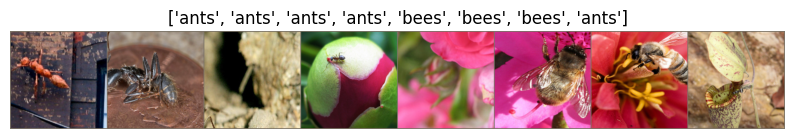

In [5]:
def imshow_tensor(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.array(IMAGENET_STD) * inp + np.array(IMAGENET_MEAN)  # un-normalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title: plt.title(title)
    plt.axis("off")

imgs, labels = next(iter(dataloaders["train"]))
grid = torchvision.utils.make_grid(imgs)
plt.figure(figsize=(10,4))
imshow_tensor(grid, title=[class_names[x] for x in labels])
plt.show()

### A.4 Load pretrained MobileNet V2 & replace the classifier

In [6]:
# Load MobileNet V2 pretrained on ImageNet
model_ft = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# ---- Feature-extraction strategy: freeze all pretrained layers ----
for param in model_ft.parameters():
    param.requires_grad = False

# The classifier of mobilenet_v2 is a Sequential; the last layer is Linear(1280 -> 1000).
# Replace it with a Linear(1280 -> 2) for our 2 classes. New layers have requires_grad=True.
num_features = model_ft.classifier[-1].in_features
model_ft.classifier[-1] = torch.nn.Linear(num_features, len(class_names))

model_ft = model_ft.to(device)

trainable = [n for n,p in model_ft.named_parameters() if p.requires_grad]
print("Trainable params:", trainable)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 105MB/s]

Trainable params: ['classifier.1.weight', 'classifier.1.bias']


### A.5 Training loop

In [7]:
def train_classifier(model, criterion, optimizer, num_epochs=5):
    best_acc = 0.0
    best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            running_loss, running_corrects = 0.0, 0
            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == "train":
                        loss.backward(); optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f"  {phase:5s} loss {epoch_loss:.4f} acc {epoch_acc:.4f}")
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    print(f"Best val acc: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return model

criterion = torch.nn.CrossEntropyLoss()
# Only the new classifier params need optimizing (feature-extraction mode)
optimizer = torch.optim.SGD(model_ft.classifier[-1].parameters(), lr=0.01, momentum=0.9)

model_ft = train_classifier(model_ft, criterion, optimizer, num_epochs=5)

Epoch 1/5
  train loss 0.4794 acc 0.7910
  val   loss 0.1700 acc 0.9477
Epoch 2/5
  train loss 1.0814 acc 0.7746
  val   loss 3.7578 acc 0.5490
Epoch 3/5
  train loss 1.4094 acc 0.8033
  val   loss 0.2240 acc 0.9477
Epoch 4/5
  train loss 0.5548 acc 0.9098
  val   loss 0.2238 acc 0.9477
Epoch 5/5
  train loss 0.9702 acc 0.8566
  val   loss 0.2283 acc 0.9281
Best val acc: 0.9477


### A.6 (Optional) Fine-tuning

To fine-tune instead of pure feature extraction, unfreeze all layers and train with a **small** learning rate:

```python
for p in model_ft.parameters():
    p.requires_grad = True
optimizer = torch.optim.SGD(model_ft.parameters(), lr=1e-4, momentum=0.9)
model_ft = train_classifier(model_ft, criterion, optimizer, num_epochs=5)
```


### A.7 Visualize predictions

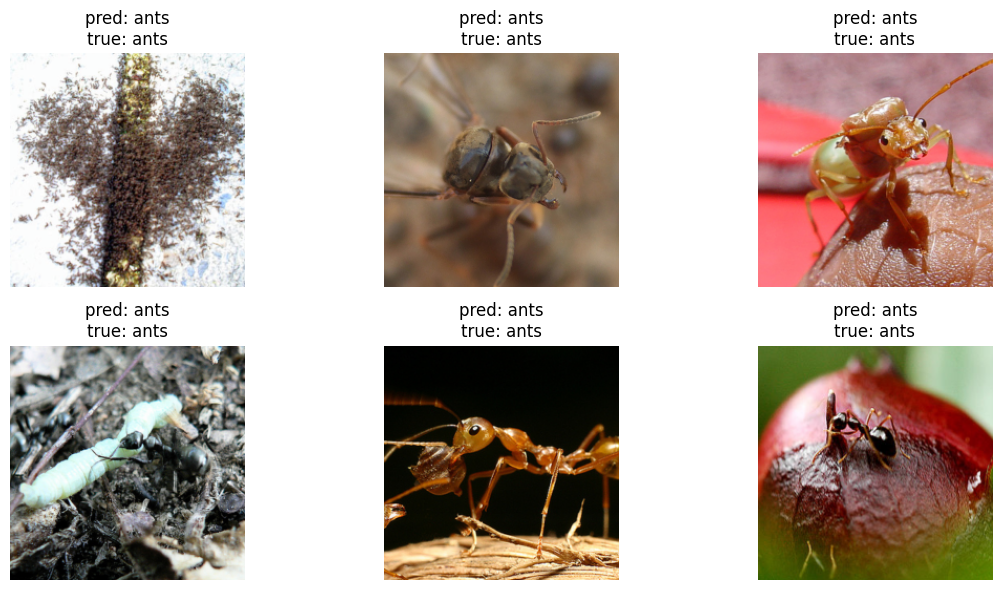

In [8]:
model_ft.eval()
inputs, labels = next(iter(dataloaders["val"]))
inputs = inputs.to(device)
with torch.no_grad():
    outputs = model_ft(inputs)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12,6))
for i in range(min(6, inputs.size(0))):
    plt.subplot(2,3,i+1)
    imshow_tensor(inputs.cpu().data[i],
                  title=f"pred: {class_names[preds[i]]}\ntrue: {class_names[labels[i]]}")
plt.tight_layout(); plt.show()

---
## Part B — Faster R-CNN for Object Detection

Faster R-CNN is a two-stage detector: a **Region Proposal Network** suggests candidate boxes, then a head classifies each box and refines its coordinates. We start from a model pretrained on **COCO** and replace only the final **box predictor** head so it outputs *our* classes:

- class `0` = background
- class `1` = pedestrian


### B.1 Download the dataset

In [9]:
download_and_extract(
    url="https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip",
    zip_name="PennFudanPed.zip",
    extract_check_dir="PennFudanPed",
)
print(os.listdir("PennFudanPed"))
# PNGImages/ = photos, PedMasks/ = per-pixel instance masks

Extracting ...
Done -> PennFudanPed
['readme.txt', 'PNGImages', 'PedMasks', 'Annotation', 'added-object-list.txt']


### B.2 A custom Dataset that returns (image, target)

In [10]:
import torch
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F

class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.imgs  = sorted(os.listdir(os.path.join(root, "PNGImages")))
        self.masks = sorted(os.listdir(os.path.join(root, "PedMasks")))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img  = read_image(img_path)                      # uint8 CxHxW
        mask = read_image(mask_path)

        # Each pedestrian is encoded by a different integer (0 = background)
        obj_ids = torch.unique(mask)[1:]                 # drop background id 0
        num_objs = len(obj_ids)
        masks = (mask == obj_ids[:, None, None]).to(torch.uint8)  # N x H x W

        boxes = masks_to_boxes(masks)                    # N x 4 (xmin,ymin,xmax,ymax)
        labels = torch.ones((num_objs,), dtype=torch.int64)       # all pedestrians -> 1
        area = (boxes[:, 3]-boxes[:, 1]) * (boxes[:, 2]-boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap in tv_tensors so torchvision v2 transforms handle boxes/masks correctly
        img = tv_tensors.Image(img)
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY",
                                              canvas_size=F.get_size(img)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": idx,
            "area": area,
            "iscrowd": iscrowd,
        }
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

### B.3 Transforms & dataloaders

In [11]:
from torchvision.transforms import v2 as T

def get_transform(train):
    tfms = [T.ToDtype(torch.float, scale=True)]      # uint8 -> float in [0,1]
    if train:
        tfms.insert(0, T.RandomHorizontalFlip(0.5))
    tfms.append(T.ToPureTensor())
    return T.Compose(tfms)

def collate_fn(batch):
    return tuple(zip(*batch))

dataset       = PennFudanDataset("PennFudanPed", get_transform(train=True))
dataset_test  = PennFudanDataset("PennFudanPed", get_transform(train=False))

# Reserve the last 50 images for validation
indices = torch.randperm(len(dataset)).tolist()
dataset      = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, num_workers=2, collate_fn=collate_fn)
data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=2, collate_fn=collate_fn)

print("train:", len(dataset), "| test:", len(dataset_test))

train: 120 | test: 50


### B.4 Build the model — pretrained Faster R-CNN, new head

In [12]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_detection_model(num_classes):
    # Load a model pretrained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    # Number of input features to the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the head with a fresh one for `num_classes` (background + pedestrian)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

num_classes = 2  # background + pedestrian
model_det = get_detection_model(num_classes).to(device)
print("Model ready. Box predictor:", model_det.roi_heads.box_predictor)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 129MB/s] 


Model ready. Box predictor: FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
)


### B.5 Training loop (self-contained)

In [ ]:
def train_detection(model, data_loader, num_epochs=2, lr=0.005):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=5e-4)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    for epoch in range(num_epochs):
        model.train()
        running = 0.0
        for i, (images, targets) in enumerate(data_loader):
            images = [img.to(device) for img in images]
            targets = [{k: (v.to(device) if torch.is_tensor(v) else v)
                        for k, v in t.items()} for t in targets]

            # In train mode the model returns a dict of losses
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            running += losses.item()
            if i % 10 == 0:
                print(f"  epoch {epoch+1} iter {i:3d}  loss {losses.item():.4f}")
        lr_scheduler.step()
        print(f"Epoch {epoch+1} avg loss {running/len(data_loader):.4f}")
    return model

# 2 epochs is enough to see it work; increase for better results.
model_det = train_detection(model_det, data_loader, num_epochs=2)

  epoch 1 iter   0  loss 0.9477


### B.6 Run inference & draw predicted boxes

In [ ]:
from torchvision.utils import draw_bounding_boxes

model_det.eval()
img, _ = dataset_test[0]
with torch.no_grad():
    prediction = model_det([img.to(device)])[0]

# Keep only confident detections
keep = prediction["scores"] > 0.7
boxes  = prediction["boxes"][keep].cpu()
scores = prediction["scores"][keep].cpu()
labels = [f"pedestrian {s:.2f}" for s in scores]

img_uint8 = (img * 255).to(torch.uint8)
drawn = draw_bounding_boxes(img_uint8, boxes, labels, colors="red", width=3)

plt.figure(figsize=(8,8))
plt.imshow(drawn.permute(1,2,0)); plt.axis("off")
plt.title(f"{len(boxes)} pedestrian(s) detected"); plt.show()

---
## Part C (Bonus) — Faster R-CNN **with a MobileNet backbone**

This is where both topics meet. Torchvision ships `fasterrcnn_mobilenet_v3_large_fpn`: a Faster R-CNN detector whose feature extractor **is** a MobileNet. It's much lighter/faster than the ResNet-50 version — great for mobile/real-time detection.

We reuse the exact same training data and loop, only swapping the model.


In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_mobilenet_detector(num_classes):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model_mb = get_mobilenet_detector(num_classes=2).to(device)

# Same training loop, same data
model_mb = train_detection(model_mb, data_loader, num_epochs=2, lr=0.005)

In [ ]:
model_mb.eval()
img, _ = dataset_test[1]
with torch.no_grad():
    pred = model_mb([img.to(device)])[0]
keep = pred["scores"] > 0.7
drawn = draw_bounding_boxes((img*255).to(torch.uint8),
                            pred["boxes"][keep].cpu(),
                            [f"ped {s:.2f}" for s in pred["scores"][keep].cpu()],
                            colors="lime", width=3)
plt.figure(figsize=(8,8))
plt.imshow(drawn.permute(1,2,0)); plt.axis("off")
plt.title("MobileNet-backbone Faster R-CNN"); plt.show()

---
## Summary

**What we did**
- **Part A:** Adapted a pretrained **MobileNet V2** to classify ants vs bees using *feature extraction* (froze the backbone, trained a new head).
- **Part B:** Fine-tuned a COCO-pretrained **Faster R-CNN** to detect pedestrians by swapping its box-predictor head.
- **Part C:** Combined both ideas with a **MobileNet-backbone Faster R-CNN** — lighter and faster.

**Datasets used**
- Hymenoptera (classification): `https://download.pytorch.org/tutorial/hymenoptera_data.zip`
- Penn-Fudan Pedestrian (detection): `https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip`
